# 🔬 CTCNet: CNN-Transformer Cooperation Network for Face Super-Resolution

**Paper:** *CTCNet: A CNN-Transformer Cooperation Network for Face Image Super-Resolution*  
**Authors:** Guangwei Gao, Zixiang Xu, Juncheng Li, Jian Yang, Tieyong Zeng, Guo-Jun Qi  
**arXiv:** 2204.08696

---

## Overview

CTCNet proposes a **U-Net style encoder-decoder** that cooperates CNN (local features) with Transformer (global structure) for ×8 face super-resolution.

### Key Components
| Module | Role |
|--------|------|
| **LGCM** (Local-Global Feature Cooperation Module) | FSAU + Transformer Block for local+global features |
| **FSAU** (Facial Structure Attention Unit) | Channel-in-spatial attention + AFDU for local facial details |
| **FRM** (Feature Refinement Module) | Bottleneck refinement with dual-branch FEU |
| **MFFU** (Multi-scale Feature Fusion Unit) | Fuses encoder features at multiple scales in decoder |
| **CTCGAN** | CTCNet + GAN for perceptual quality (extended model) |

### Architecture Flow
```
LR Input (16×16) → Shallow Conv → Encoder (3 stages, LGCM + Downsample)
    → Bottleneck (4× FRM) → Decoder (3 stages, Upsample + MFFU + LGCM) → SR Output (128×128)
```

> **GPU required.** Enable: Runtime → Change runtime type → GPU (T4 recommended)

## 1. Install Dependencies

In [ ]:
!pip install -q torch torchvision einops timm scikit-image lpips
!pip install -q gdown  # for CelebA download helper

import torch
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 2.4 MB/s eta 0:00:00
PyTorch version: 2.9.0+cu128
CUDA available: True
GPU: Tesla T4


## 2. Imports

In [ ]:
import os
import math
import time
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision
import torchvision.transforms as transforms
import torchvision.transforms.functional as TF

from einops import rearrange

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


## 3. Building Blocks

### 3.1 Channel Attention (CA)

In [ ]:
class ChannelAttention(nn.Module):
    """Squeeze-and-Excitation channel attention [Zhang et al., RCAN]."""
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Conv2d(channels, channels // reduction, 1, bias=False),
            nn.ReLU(inplace=True),
            nn.Conv2d(channels // reduction, channels, 1, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        return x * self.fc(self.avg_pool(x))

### 3.2 Adaptive Feature Distillation Unit (AFDU)

In [ ]:
class AFDU(nn.Module):
    """
    Adaptive Feature Distillation Unit (AFDU).
    Reduction → Expansion → Concat → Conv 1x1 → Conv 3x3 → CA → Conv 3x3
    with residual connection.
    """
    def __init__(self, channels):
        super().__init__()
        mid = channels // 2
        # Reduction and Expansion (both 3x3 conv)
        self.reduction = nn.Conv2d(channels, mid, 3, padding=1)
        self.expansion = nn.Conv2d(mid, channels, 3, padding=1)
        # After concat: 2*channels -> channels
        self.conv1x1 = nn.Conv2d(2 * channels, channels, 1)
        self.conv3x3 = nn.Conv2d(channels, channels, 3, padding=1)
        self.ca = ChannelAttention(channels)
        self.refine = nn.Conv2d(channels, channels, 3, padding=1)
        self.lrelu = nn.LeakyReLU(0.2, inplace=True)

    def forward(self, x):
        reduced = self.lrelu(self.reduction(x))
        expanded = self.lrelu(self.expansion(reduced))
        fused = self.lrelu(self.conv1x1(torch.cat([x, expanded], dim=1)))
        fused = self.lrelu(self.conv3x3(fused))
        fused = self.ca(fused)
        out = self.refine(fused)
        return out + x  # residual

### 3.3 Hourglass Structure for FSAU

In [ ]:
class HourglassBlock(nn.Module):
    """Small hourglass to capture multi-scale facial landmarks."""
    def __init__(self, channels):
        super().__init__()
        self.down1 = nn.Sequential(
            nn.Conv2d(channels, channels, 3, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True)
        )
        self.down2 = nn.Sequential(
            nn.Conv2d(channels, channels, 3, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True)
        )
        self.middle = nn.Sequential(
            nn.Conv2d(channels, channels, 3, padding=1),
            nn.LeakyReLU(0.2, inplace=True)
        )
        self.up2 = nn.Sequential(
            nn.ConvTranspose2d(channels, channels, 4, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True)
        )
        self.up1 = nn.Sequential(
            nn.ConvTranspose2d(channels, channels, 4, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True)
        )

    def forward(self, x):
        d1 = self.down1(x)
        d2 = self.down2(d1)
        m = self.middle(d2)
        u2 = self.up2(m)
        # Handle potential size mismatch
        u2 = u2[:, :, :d1.shape[2], :d1.shape[3]]
        u1 = self.up1(u2 + d1)
        u1 = u1[:, :, :x.shape[2], :x.shape[3]]
        return u1

### 3.4 Facial Structure Attention Unit (FSAU)

Core CNN module: AFDU → AttentionUnit (Hourglass + CA nested in SA) → AFDU

In [ ]:
class FSAU(nn.Module):
    """
    Facial Structure Attention Unit.
    AFDU → [Hourglass + CA (channel-in-spatial attention)] → AFDU
    """
    def __init__(self, channels):
        super().__init__()
        self.afdu1 = AFDU(channels)
        self.hourglass = HourglassBlock(channels)
        self.ca = ChannelAttention(channels)
        # Spatial attention map generation
        self.spatial_conv = nn.Conv2d(channels, channels, 3, padding=1)
        self.spatial_sig = nn.Sigmoid()
        self.afdu2 = AFDU(channels)

    def forward(self, x):
        feat = self.afdu1(x)

        # Attention Unit: hourglass captures multi-scale landmarks
        hg = self.hourglass(feat)
        hg_ca = self.ca(hg)          # channel attention on hourglass output
        hg_ca = hg_ca + feat         # residual from input to hourglass

        # Spatial attention map
        sa_map = self.spatial_sig(self.spatial_conv(hg_ca))
        attended = feat * sa_map     # element-wise multiply

        out = self.afdu2(attended)
        return out

### 3.5 Transformer Block with MDTA + GDFN

Based on **Restormer** (Zamir et al.) with:
- **MDTA**: Multi-Dconv Head Transposed Attention — C×C attention map instead of HW×HW
- **GDFN**: Gated-Dconv Feed-Forward Network

In [ ]:
class MDTA(nn.Module):
    """
    Multi-Dconv Head Transposed Attention.
    Generates Q,K,V via 1x1 pointwise + 3x3 depthwise conv.
    Attention map is C×C (not HW×HW) for efficiency.
    """
    def __init__(self, channels, num_heads):
        super().__init__()
        self.num_heads = num_heads
        self.temperature = nn.Parameter(torch.ones(num_heads, 1, 1))

        self.qkv = nn.Conv2d(channels, channels * 3, 1, bias=False)
        self.qkv_dw = nn.Conv2d(channels * 3, channels * 3, 3,
                                 padding=1, groups=channels * 3, bias=False)
        self.proj = nn.Conv2d(channels, channels, 1, bias=False)

    def forward(self, x):
        B, C, H, W = x.shape
        qkv = self.qkv_dw(self.qkv(x))       # B, 3C, H, W
        q, k, v = qkv.chunk(3, dim=1)         # each: B, C, H, W

        # Reshape for multi-head: B*heads, C//heads, H*W
        head_dim = C // self.num_heads
        q = rearrange(q, 'b (h d) x y -> b h d (x y)', h=self.num_heads)
        k = rearrange(k, 'b (h d) x y -> b h d (x y)', h=self.num_heads)
        v = rearrange(v, 'b (h d) x y -> b h d (x y)', h=self.num_heads)

        # Normalize
        q = F.normalize(q, dim=-1)
        k = F.normalize(k, dim=-1)

        # Transposed attention: d×d attention map (not N×N)
        attn = (q @ k.transpose(-2, -1)) * self.temperature  # B, heads, d, d
        attn = attn.softmax(dim=-1)

        out = attn @ v                          # B, heads, d, N
        out = rearrange(out, 'b h d (x y) -> b (h d) x y', x=H, y=W)
        return self.proj(out)


class GDFN(nn.Module):
    """
    Gated-Dconv Feed-Forward Network.
    Expands channels → depthwise conv → gate with GELU → project back.
    """
    def __init__(self, channels, expansion=2.66):
        super().__init__()
        hidden = int(channels * expansion)
        self.proj_in = nn.Conv2d(channels, hidden * 2, 1, bias=False)
        self.dw_conv = nn.Conv2d(hidden * 2, hidden * 2, 3,
                                  padding=1, groups=hidden * 2, bias=False)
        self.proj_out = nn.Conv2d(hidden, channels, 1, bias=False)

    def forward(self, x):
        x1 = self.dw_conv(self.proj_in(x))    # B, 2*hidden, H, W
        x1, x2 = x1.chunk(2, dim=1)           # each: B, hidden, H, W
        out = x1 * F.gelu(x2)                 # gated activation
        return self.proj_out(out)


class TransformerBlock(nn.Module):
    """Restormer-style Transformer block: LayerNorm + MDTA + LayerNorm + GDFN."""
    def __init__(self, channels, num_heads=4):
        super().__init__()
        self.norm1 = nn.LayerNorm(channels)
        self.attn = MDTA(channels, num_heads)
        self.norm2 = nn.LayerNorm(channels)
        self.ffn = GDFN(channels)

    def _norm(self, x, norm):
        """Apply LayerNorm over channel dimension (works on B,C,H,W)."""
        B, C, H, W = x.shape
        x = x.permute(0, 2, 3, 1)    # B, H, W, C
        x = norm(x)
        return x.permute(0, 3, 1, 2)  # B, C, H, W

    def forward(self, x):
        x = x + self.attn(self._norm(x, self.norm1))
        x = x + self.ffn(self._norm(x, self.norm2))
        return x

### 3.6 Local-Global Feature Cooperation Module (LGCM)

FSAU (local) + TransformerBlock (global) with residual add

In [ ]:
class LGCM(nn.Module):
    """
    Local-Global Feature Cooperation Module.
    FSAU captures local details, TransformerBlock captures global structure.
    Their outputs are fused via addition.
    """
    def __init__(self, channels, num_heads=4):
        super().__init__()
        self.fsau = FSAU(channels)
        self.transformer = TransformerBlock(channels, num_heads)

    def forward(self, x):
        local_feat = self.fsau(x)
        global_feat = self.transformer(x)
        return local_feat + global_feat

### 3.7 Feature Enhancement Unit (FEU) — Dual-Branch

In [ ]:
class FEU(nn.Module):
    """
    Feature Enhancement Unit.
    Dual-branch: branch1 = original scale AFDU chain;
                 branch2 = downsampled AFDU, then upsampled and fused.
    Self-calibration path on residual connection.
    Equations (9)-(12) from paper.
    """
    def __init__(self, channels):
        super().__init__()
        # Branch 1 (original scale)
        self.afdu_in1  = AFDU(channels)
        self.afdu_in2  = AFDU(channels)
        # Branch 2 (downsampled scale)
        self.afdu_low1 = AFDU(channels)
        self.afdu_low2 = AFDU(channels)
        self.downsample = nn.AvgPool2d(2)

        # Fusion convolutions (concat along channel → 2C → C)
        self.fuse1 = nn.Conv2d(channels * 2, channels, 1)
        self.fuse2 = nn.Conv2d(channels * 2, channels, 1)

        # Final AFDU + output
        self.afdu_out = AFDU(channels)

        # Self-calibration path
        self.calibration = nn.Sequential(
            nn.Conv2d(channels, channels, 1),
            nn.Sigmoid()
        )
        self.lrelu = nn.LeakyReLU(0.2, inplace=True)

    def forward(self, x):
        # Eq. 9
        f_in   = self.afdu_in1(x)
        f_low  = self.afdu_low1(self.downsample(x))
        f_low2 = self.afdu_low2(f_low)

        # Eq. 10: fuse branch1 + upsampled branch2
        f_low_up = F.interpolate(f_low, size=f_in.shape[2:], mode='bilinear', align_corners=False)
        f_in2 = self.lrelu(
            self.fuse1(torch.cat([self.afdu_in1(f_in), self.afdu_low1(f_low_up)], dim=1))
        )

        # Eq. 11: second round of fusion
        f_low2_up = F.interpolate(f_low2, size=f_in2.shape[2:], mode='bilinear', align_corners=False)
        f_in3 = self.lrelu(
            self.fuse2(torch.cat([self.afdu_in2(f_in2), self.afdu_low2(f_low2_up)], dim=1))
        )

        # Eq. 12: final AFDU + self-calibrated residual
        out = self.afdu_out(f_in3) + x * self.calibration(x)
        return out

### 3.8 Feature Refinement Module (FRM)

In [ ]:
class FRM(nn.Module):
    """Feature Refinement Module = FSAU + FEU."""
    def __init__(self, channels):
        super().__init__()
        self.fsau = FSAU(channels)
        self.feu = FEU(channels)

    def forward(self, x):
        return self.feu(self.fsau(x))

### 3.9 Multi-scale Feature Fusion Unit (MFFU)

Fuses encoder features at 3 different scales with the current decoder feature map.

In [ ]:
class MFFU(nn.Module):
    """
    Multi-scale Feature Fusion Unit.
    Takes 3 encoder feature maps (E128, E64, E32 for a 128 input) + current decoder feat.
    Rescales all to target size → Concat (4× channels) → Conv1x1 → ChannelAttention.
    Equations (13)-(16) from paper.
    """
    def __init__(self, channels_list, target_channels):
        """
        channels_list: list of [enc_stage1_c, enc_stage2_c, enc_stage3_c]
        target_channels: channels of current decoder feature map
        """
        super().__init__()
        total_in = sum(channels_list) + target_channels
        self.fuse = nn.Conv2d(total_in, target_channels, 1)
        self.ca = ChannelAttention(target_channels)

    def forward(self, enc_feats, dec_feat):
        """
        enc_feats: list of encoder feature maps (varying spatial sizes)
        dec_feat: current decoder feature map (target spatial size)
        """
        H, W = dec_feat.shape[2], dec_feat.shape[3]
        resized = []
        for ef in enc_feats:
            if ef.shape[2] != H or ef.shape[3] != W:
                ef = F.interpolate(ef, size=(H, W), mode='bilinear', align_corners=False)
            resized.append(ef)
        resized.append(dec_feat)

        fused = self.fuse(torch.cat(resized, dim=1))
        return self.ca(fused)

## 4. Full CTCNet Architecture

In [ ]:
class CTCNet(nn.Module):
    """
    CNN-Transformer Cooperation Network (CTCNet).

    Architecture:
      Input (3×H×W)
        → Shallow Conv (3×3, C channels)
        → Encoder Stage 1: LGCM → Downsample (C → 2C, H/2)
        → Encoder Stage 2: LGCM → Downsample (2C → 4C, H/4)
        → Encoder Stage 3: LGCM → Downsample (4C → 4C, H/8)  [channels capped]
        → Bottleneck: N × FRM
        → Decoder Stage 1: Upsample → MFFU → LGCM (4C → 4C)
        → Decoder Stage 2: Upsample → MFFU → LGCM (4C → 2C)
        → Decoder Stage 3: Upsample → MFFU → LGCM (2C → C)
        → Output Conv (3×3)
      ISR = ILR_upsampled + IOut
    """
    def __init__(self, base_channels=32, num_frm=4, num_heads=4, scale=8):
        super().__init__()

        self.C = base_channels
        self.scale = scale
        C = self.C

        # ── Shallow feature extraction ─────────────────────────────
        self.shallow_conv = nn.Conv2d(3, C, 3, padding=1)

        # ── Encoder ───────────────────────────────────────────────
        self.enc_lgcm1 = LGCM(C, num_heads)
        self.downsample1 = self._make_downsample(C, C * 2)

        self.enc_lgcm2 = LGCM(C * 2, num_heads)
        self.downsample2 = self._make_downsample(C * 2, C * 4)

        self.enc_lgcm3 = LGCM(C * 4, num_heads)
        self.downsample3 = self._make_downsample(C * 4, C * 4)

        # ── Bottleneck ────────────────────────────────────────────
        self.bottleneck = nn.Sequential(*[FRM(C * 4) for _ in range(num_frm)])

        # ── Decoder ───────────────────────────────────────────────
        self.upsample1 = self._make_upsample(C * 4, C * 4)
        self.mffu1 = MFFU([C, C * 2, C * 4], C * 4)
        self.dec_lgcm1 = LGCM(C * 4, num_heads)

        self.upsample2 = self._make_upsample(C * 4, C * 2)
        self.mffu2 = MFFU([C, C * 2, C * 4], C * 2)
        self.dec_lgcm2 = LGCM(C * 2, num_heads)

        self.upsample3 = self._make_upsample(C * 2, C)
        self.mffu3 = MFFU([C, C * 2, C * 4], C)
        self.dec_lgcm3 = LGCM(C, num_heads)

        # ── SR Head ───────────────────────────────────────────────
        self.sr_head = nn.Sequential(
            nn.Conv2d(C, C * scale * scale, 3, padding=1),
            nn.PixelShuffle(scale),
            nn.Conv2d(C, 3, 3, padding=1)
        )

        # Residual upsample
        self.upsample_lr = nn.Upsample(
            scale_factor=scale,
            mode="bicubic",
            align_corners=False
        )

    def _make_downsample(self, in_c, out_c):
        """3x3 stride-2 conv + LeakyReLU + 3x3 stride-1 conv."""
        return nn.Sequential(
            nn.Conv2d(in_c, out_c, 3, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(out_c, out_c, 3, padding=1)
        )

    def _make_upsample(self, in_c, out_c):
        """6x6 transposed conv stride-2 + LeakyReLU + 3x3 conv."""
        return nn.Sequential(
            nn.ConvTranspose2d(in_c, out_c, 6, stride=2, padding=2),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(out_c, out_c, 3, padding=1)
        )

    def forward(self, x_lr):
        f0 = self.shallow_conv(x_lr)

        e1 = self.enc_lgcm1(f0)
        e1d = self.downsample1(e1)

        e2 = self.enc_lgcm2(e1d)
        e2d = self.downsample2(e2)

        e3 = self.enc_lgcm3(e2d)
        e3d = self.downsample3(e3)

        bn = self.bottleneck(e3d)

        d1 = self.upsample1(bn)
        d1 = self.mffu1([e1, e2, e3], d1)
        d1 = self.dec_lgcm1(d1)

        d2 = self.upsample2(d1)
        d2 = self.mffu2([e1, e2, e3], d2)
        d2 = self.dec_lgcm2(d2)

        d3 = self.upsample3(d2)
        d3 = self.mffu3([e1, e2, e3], d3)
        d3 = self.dec_lgcm3(d3)

        # SR Output
        i_out = self.sr_head(d3)
        i_lr_up = self.upsample_lr(x_lr)

        return torch.clamp(i_lr_up + i_out, 0.0, 1.0)

In [ ]:
# ── Quick sanity check ────────────────────────────────────────────────────────
model = CTCNet(base_channels=32, num_frm=4, num_heads=4, scale=8).to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Approx model size: ~{total_params * 4 / 1e6:.1f} MB")

# Forward pass test: 16×16 LR → 128×128 SR
with torch.no_grad():
    dummy_lr = torch.rand(2, 3, 16, 16).to(device)
    dummy_sr = model(dummy_lr)
    print(f"\nInput shape:  {dummy_lr.shape}")
    print(f"Output shape: {dummy_sr.shape}")
    print(f"Output range: [{dummy_sr.min():.3f}, {dummy_sr.max():.3f}]")
print("\n✅ CTCNet forward pass OK!")

Total parameters:     26,558,855
Trainable parameters: 26,558,855
Approx model size: ~106.2 MB

Input shape:  torch.Size([2, 3, 16, 16])
Output shape: torch.Size([2, 3, 128, 128])
Output range: [0.000, 1.000]

✅ CTCNet forward pass OK!


## 5. CTCGAN: GAN Extension

The paper extends CTCNet with GAN training using pixel loss + perceptual loss + adversarial loss.

In [ ]:
class Discriminator(nn.Module):
    """PatchGAN-style discriminator (conditional)."""
    def __init__(self, in_channels=3):
        super().__init__()

        def disc_block(in_c, out_c, stride=2, normalize=True):
            layers = [nn.Conv2d(in_c, out_c, 4, stride, 1, bias=not normalize)]
            if normalize:
                layers.append(nn.BatchNorm2d(out_c))
            layers.append(nn.LeakyReLU(0.2, inplace=True))
            return layers

        self.model = nn.Sequential(
            *disc_block(in_channels * 2, 64, normalize=False),
            *disc_block(64, 128),
            *disc_block(128, 256),
            *disc_block(256, 512, stride=1),
            nn.Conv2d(512, 1, 4, 1, 1)
        )

    def forward(self, lr_up, hr):
        """Concatenate upsampled LR + HR (or SR) as condition."""
        return self.model(torch.cat([lr_up, hr], dim=1))


class VGGPerceptualLoss(nn.Module):
    """VGG19-based perceptual loss (feature-level L1)."""
    def __init__(self):
        super().__init__()
        vgg = torchvision.models.vgg19(pretrained=True)
        # Use features up to relu3_4 (index 18)
        self.features = nn.Sequential(*list(vgg.features.children())[:18]).eval()
        for p in self.features.parameters():
            p.requires_grad = False

    def forward(self, sr, hr):
        return F.l1_loss(self.features(sr), self.features(hr))

## 6. Dataset

We use a subset of **CelebA** (or any face image folder). The paper trains on 18,000 CelebA images cropped/resized to 128×128 HR, downsampled 8× to 16×16 LR.

In [ ]:
class FaceSRDataset(Dataset):
    """
    Face super-resolution dataset.
    HR: 128×128 center-cropped face images
    LR: 16×16 bicubic downsampled (×8 scale)
    """
    def __init__(self, image_dir, hr_size=128, scale=8, augment=True):
        self.image_paths = sorted(list(Path(image_dir).glob('*.jpg')) +
                                   list(Path(image_dir).glob('*.png')) +
                                   list(Path(image_dir).glob('*.jpeg')))
        self.hr_size = hr_size
        self.lr_size = hr_size // scale
        self.augment = augment

        self.hr_transform = transforms.Compose([
            transforms.CenterCrop(min(hr_size * 2, 178)),  # handle celeba 218x178
            transforms.Resize(hr_size, interpolation=transforms.InterpolationMode.BICUBIC),
            transforms.ToTensor()
        ])

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert('RGB')
        hr = self.hr_transform(img)

        # Augmentation: random horizontal flip
        if self.augment and random.random() > 0.5:
            hr = TF.hflip(hr)

        # Bicubic downsample to get LR
        lr_pil = TF.to_pil_image(hr)
        lr_pil = lr_pil.resize((self.lr_size, self.lr_size), Image.BICUBIC)
        lr = TF.to_tensor(lr_pil)

        return lr, hr

In [36]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [38]:
# ── Download CelebA (subset) ─────────────────────────────────────────────────
# Option A: Download a small subset via torchvision (requires Google Drive access)
# Option B: Use your own images

DATA_DIR = '/content/drive/MyDrive/TESIS/celeba/celeba'
os.makedirs(DATA_DIR, exist_ok=True)

# Try downloading CelebA via torchvision
try:
    if not os.path.exists(DATA_DIR):
        raise FileNotFoundError(
            f"Dataset folder not found: {DATA_DIR}\n"
            "Make sure you uploaded images into Google Drive."
        )

    # Count images
    image_files = list(Path(DATA_DIR).glob("*.jpg"))

    print(f"✅ Total images found in Google Drive: {len(image_files)}")
    print("Example files:", image_files[:5])

except Exception as e:
    print(f"CelebA download failed: {e}")
    print("\n⚠️  Generating synthetic face-like images for demo...")

    # Fallback: generate random synthetic images for demo
    from PIL import ImageDraw
    save_dir = Path(DATA_DIR)
    for i in range(500):
        # Simple synthetic colored face-like image
        img = Image.new('RGB', (128, 128))
        draw = ImageDraw.Draw(img)
        # Background
        r, g, b = random.randint(150,220), random.randint(100,170), random.randint(80,140)
        draw.rectangle([0,0,128,128], fill=(r,g,b))
        # "Face" oval
        draw.ellipse([20,10,108,118], fill=(r-30,g-20,b-10))
        # Add some noise-like detail
        arr = np.array(img, dtype=np.float32)
        arr += np.random.normal(0, 15, arr.shape)
        arr = np.clip(arr, 0, 255).astype(np.uint8)
        Image.fromarray(arr).save(save_dir / f"{i:05d}.jpg")
    print(f"✅ Generated 500 synthetic images in {DATA_DIR}")

# Count images
n_imgs = len(list(Path(DATA_DIR).glob('*.jpg')))
print(f"\nTotal images available: {n_imgs}")

✅ Total images found in Google Drive: 1000
Example files: [PosixPath('/content/drive/MyDrive/TESIS/celeba/celeba/000018.jpg'), PosixPath('/content/drive/MyDrive/TESIS/celeba/celeba/000005.jpg'), PosixPath('/content/drive/MyDrive/TESIS/celeba/celeba/000017.jpg'), PosixPath('/content/drive/MyDrive/TESIS/celeba/celeba/000015.jpg'), PosixPath('/content/drive/MyDrive/TESIS/celeba/celeba/000020.jpg')]

Total images available: 1000


In [39]:
# ── Build Dataset splits ─────────────────────────────────────────────────────
all_files = sorted(list(Path(DATA_DIR).glob('*.jpg')))
n_total = len(all_files)

# Split: 80% train / 10% val / 10% test
n_train = max(int(n_total * 0.80), 1)
n_val   = max(int(n_total * 0.10), 1)

# Create split dirs
for split in ['train', 'val', 'test']:
    os.makedirs(f'{DATA_DIR}/{split}', exist_ok=True)

import shutil
for i, f in enumerate(all_files):
    if i < n_train:
        shutil.copy(f, f'{DATA_DIR}/train/{f.name}')
    elif i < n_train + n_val:
        shutil.copy(f, f'{DATA_DIR}/val/{f.name}')
    else:
        shutil.copy(f, f'{DATA_DIR}/test/{f.name}')

train_dataset = FaceSRDataset(f'{DATA_DIR}/train', hr_size=128, scale=8, augment=True)
val_dataset   = FaceSRDataset(f'{DATA_DIR}/val',   hr_size=128, scale=8, augment=False)
test_dataset  = FaceSRDataset(f'{DATA_DIR}/test',  hr_size=128, scale=8, augment=False)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True,
                           num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=4, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=4, shuffle=False, num_workers=2)

print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")

# Preview a sample
lr_sample, hr_sample = train_dataset[0]
print(f"LR shape: {lr_sample.shape} | HR shape: {hr_sample.shape}")

Train: 800 | Val: 100 | Test: 100
LR shape: torch.Size([3, 16, 16]) | HR shape: torch.Size([3, 128, 128])


## 7. Metrics (PSNR, SSIM, LPIPS, VIF)

In [40]:
import lpips as lpips_lib
from skimage.metrics import structural_similarity as sk_ssim

lpips_fn = lpips_lib.LPIPS(net='vgg').to(device)

def compute_psnr(sr, hr):
    """PSNR between two tensors in [0,1]."""
    mse = F.mse_loss(sr, hr)
    if mse == 0:
        return float('inf')
    return 10 * torch.log10(1.0 / mse).item()

def compute_ssim(sr, hr):
    """SSIM averaged over batch."""
    sr_np = sr.detach().cpu().numpy().transpose(0, 2, 3, 1)  # B,H,W,C
    hr_np = hr.detach().cpu().numpy().transpose(0, 2, 3, 1)
    ssim_vals = [
        sk_ssim(sr_np[i], hr_np[i], channel_axis=2, data_range=1.0)
        for i in range(sr_np.shape[0])
    ]
    return np.mean(ssim_vals)

def compute_lpips(sr, hr):
    """LPIPS (lower is better)."""
    # Normalize to [-1, 1]
    sr_n = sr * 2 - 1
    hr_n = hr * 2 - 1
    with torch.no_grad():
        return lpips_fn(sr_n, hr_n).mean().item()

@torch.no_grad()
def evaluate(model, dataloader, max_batches=None):
    model.eval()
    psnr_list, ssim_list, lpips_list = [], [], []

    for i, (lr, hr) in enumerate(dataloader):
        if max_batches and i >= max_batches:
            break
        lr, hr = lr.to(device), hr.to(device)
        sr = model(lr)
        sr = torch.clamp(sr, 0, 1)

        psnr_list.append(compute_psnr(sr, hr))
        ssim_list.append(compute_ssim(sr, hr))
        lpips_list.append(compute_lpips(sr, hr))

    return {
        'PSNR': np.mean(psnr_list),
        'SSIM': np.mean(ssim_list),
        'LPIPS': np.mean(lpips_list)
    }

print("✅ Metrics ready.")

Setting up [LPIPS] perceptual loss: trunk [vgg], v[0.1], spatial [off]


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/vgg.pth
✅ Metrics ready.


## 8. Training: CTCNet (Pixel Loss)

The paper uses **L1 pixel loss** with **Adam** optimizer, lr = 2e-4.

In [41]:
def train_ctcnet(
    model, train_loader, val_loader,
    num_epochs=30,
    lr=2e-4,
    save_path='/content/ctcnet_best.pth',
    log_interval=5
):
    optimizer = optim.Adam(model.parameters(), lr=lr, betas=(0.9, 0.99))
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs, eta_min=1e-6)

    history = {'train_loss': [], 'val_psnr': [], 'val_ssim': [], 'val_lpips': []}
    best_psnr = 0.0

    for epoch in range(1, num_epochs + 1):
        model.train()
        epoch_loss = 0.0
        t0 = time.time()

        for batch_idx, (lr, hr) in enumerate(train_loader):
            lr, hr = lr.to(device), hr.to(device)
            sr = model(lr)

            loss = F.l1_loss(sr, hr)   # Eq. (1) from paper

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()

        scheduler.step()
        avg_loss = epoch_loss / len(train_loader)
        history['train_loss'].append(avg_loss)

        # Validation
        if epoch % log_interval == 0 or epoch == 1:
            metrics = evaluate(model, val_loader, max_batches=20)
            history['val_psnr'].append(metrics['PSNR'])
            history['val_ssim'].append(metrics['SSIM'])
            history['val_lpips'].append(metrics['LPIPS'])

            elapsed = time.time() - t0
            print(f"Epoch [{epoch:03d}/{num_epochs}] "
                  f"Loss: {avg_loss:.4f} | "
                  f"PSNR: {metrics['PSNR']:.2f} dB | "
                  f"SSIM: {metrics['SSIM']:.4f} | "
                  f"LPIPS: {metrics['LPIPS']:.4f} | "
                  f"LR: {scheduler.get_last_lr()[0]:.2e} | "
                  f"{elapsed:.1f}s")

            if metrics['PSNR'] > best_psnr:
                best_psnr = metrics['PSNR']
                torch.save({'epoch': epoch,
                            'model_state_dict': model.state_dict(),
                            'optimizer_state_dict': optimizer.state_dict(),
                            'psnr': best_psnr}, save_path)
                print(f"  💾 Saved best model (PSNR={best_psnr:.2f} dB)")
        else:
            elapsed = time.time() - t0
            print(f"Epoch [{epoch:03d}/{num_epochs}] Loss: {avg_loss:.4f} | {elapsed:.1f}s")

    print(f"\n✅ Training complete. Best PSNR: {best_psnr:.2f} dB")
    return history

In [42]:
# ── Train CTCNet ─────────────────────────────────────────────────────────────
model = CTCNet(base_channels=32, num_frm=4, num_heads=4, scale=8).to(device)

# Paper trains for many epochs on 18k CelebA images.
# Here we run 20 epochs as a demo — increase NUM_EPOCHS for full training.
NUM_EPOCHS = 20

print(f"Starting CTCNet training for {NUM_EPOCHS} epochs...")
history = train_ctcnet(
    model, train_loader, val_loader,
    num_epochs=NUM_EPOCHS,
    lr=2e-4,
    save_path='/content/ctcnet_best.pth',
    log_interval=5
)

Starting CTCNet training for 20 epochs...
Epoch [001/20] Loss: 0.0531 | PSNR: 22.34 dB | SSIM: 0.6216 | LPIPS: 0.4486 | LR: 1.99e-04 | 27.1s
  💾 Saved best model (PSNR=22.34 dB)
Epoch [002/20] Loss: 0.0500 | 20.5s
Epoch [003/20] Loss: 0.0489 | 19.3s
Epoch [004/20] Loss: 0.0477 | 19.5s
Epoch [005/20] Loss: 0.0468 | PSNR: 23.02 dB | SSIM: 0.6568 | LPIPS: 0.3677 | LR: 1.71e-04 | 22.1s
  💾 Saved best model (PSNR=23.02 dB)
Epoch [006/20] Loss: 0.0462 | 21.4s
Epoch [007/20] Loss: 0.0456 | 19.1s
Epoch [008/20] Loss: 0.0452 | 21.3s
Epoch [009/20] Loss: 0.0448 | 19.2s
Epoch [010/20] Loss: 0.0445 | PSNR: 23.26 dB | SSIM: 0.6705 | LPIPS: 0.3493 | LR: 1.01e-04 | 22.8s
  💾 Saved best model (PSNR=23.26 dB)
Epoch [011/20] Loss: 0.0441 | 19.8s
Epoch [012/20] Loss: 0.0439 | 20.1s
Epoch [013/20] Loss: 0.0436 | 19.1s
Epoch [014/20] Loss: 0.0434 | 20.3s
Epoch [015/20] Loss: 0.0433 | PSNR: 23.33 dB | SSIM: 0.6745 | LPIPS: 0.3467 | LR: 3.01e-05 | 21.7s
  💾 Saved best model (PSNR=23.33 dB)
Epoch [016/20] Los

## 9. Training Curves

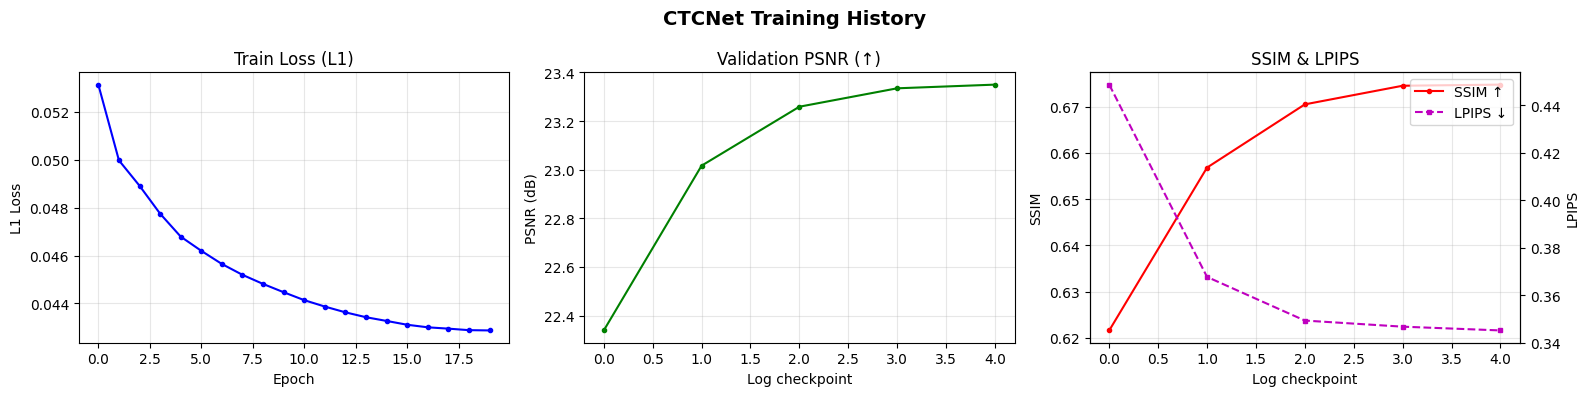

Saved: /content/ctcnet_training_curves.png


In [43]:
def plot_history(history):
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    fig.suptitle('CTCNet Training History', fontsize=14, fontweight='bold')

    axes[0].plot(history['train_loss'], 'b-o', markersize=3)
    axes[0].set_title('Train Loss (L1)')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('L1 Loss')
    axes[0].grid(alpha=0.3)

    log_epochs = list(range(0, len(history['val_psnr'])))

    axes[1].plot(log_epochs, history['val_psnr'], 'g-o', markersize=3)
    axes[1].set_title('Validation PSNR (↑)')
    axes[1].set_xlabel('Log checkpoint')
    axes[1].set_ylabel('PSNR (dB)')
    axes[1].grid(alpha=0.3)

    axes[2].plot(log_epochs, history['val_ssim'], 'r-o', markersize=3, label='SSIM ↑')
    ax2 = axes[2].twinx()
    ax2.plot(log_epochs, history['val_lpips'], 'm--s', markersize=3, label='LPIPS ↓')
    axes[2].set_title('SSIM & LPIPS')
    axes[2].set_xlabel('Log checkpoint')
    axes[2].set_ylabel('SSIM')
    ax2.set_ylabel('LPIPS')
    axes[2].grid(alpha=0.3)

    # Combined legend
    lines1, labels1 = axes[2].get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    axes[2].legend(lines1 + lines2, labels1 + labels2, loc='upper right')

    plt.tight_layout()
    plt.savefig('/content/ctcnet_training_curves.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: /content/ctcnet_training_curves.png")

plot_history(history)

## 10. Visual Results

Loaded best model from epoch 20 with PSNR=23.35 dB


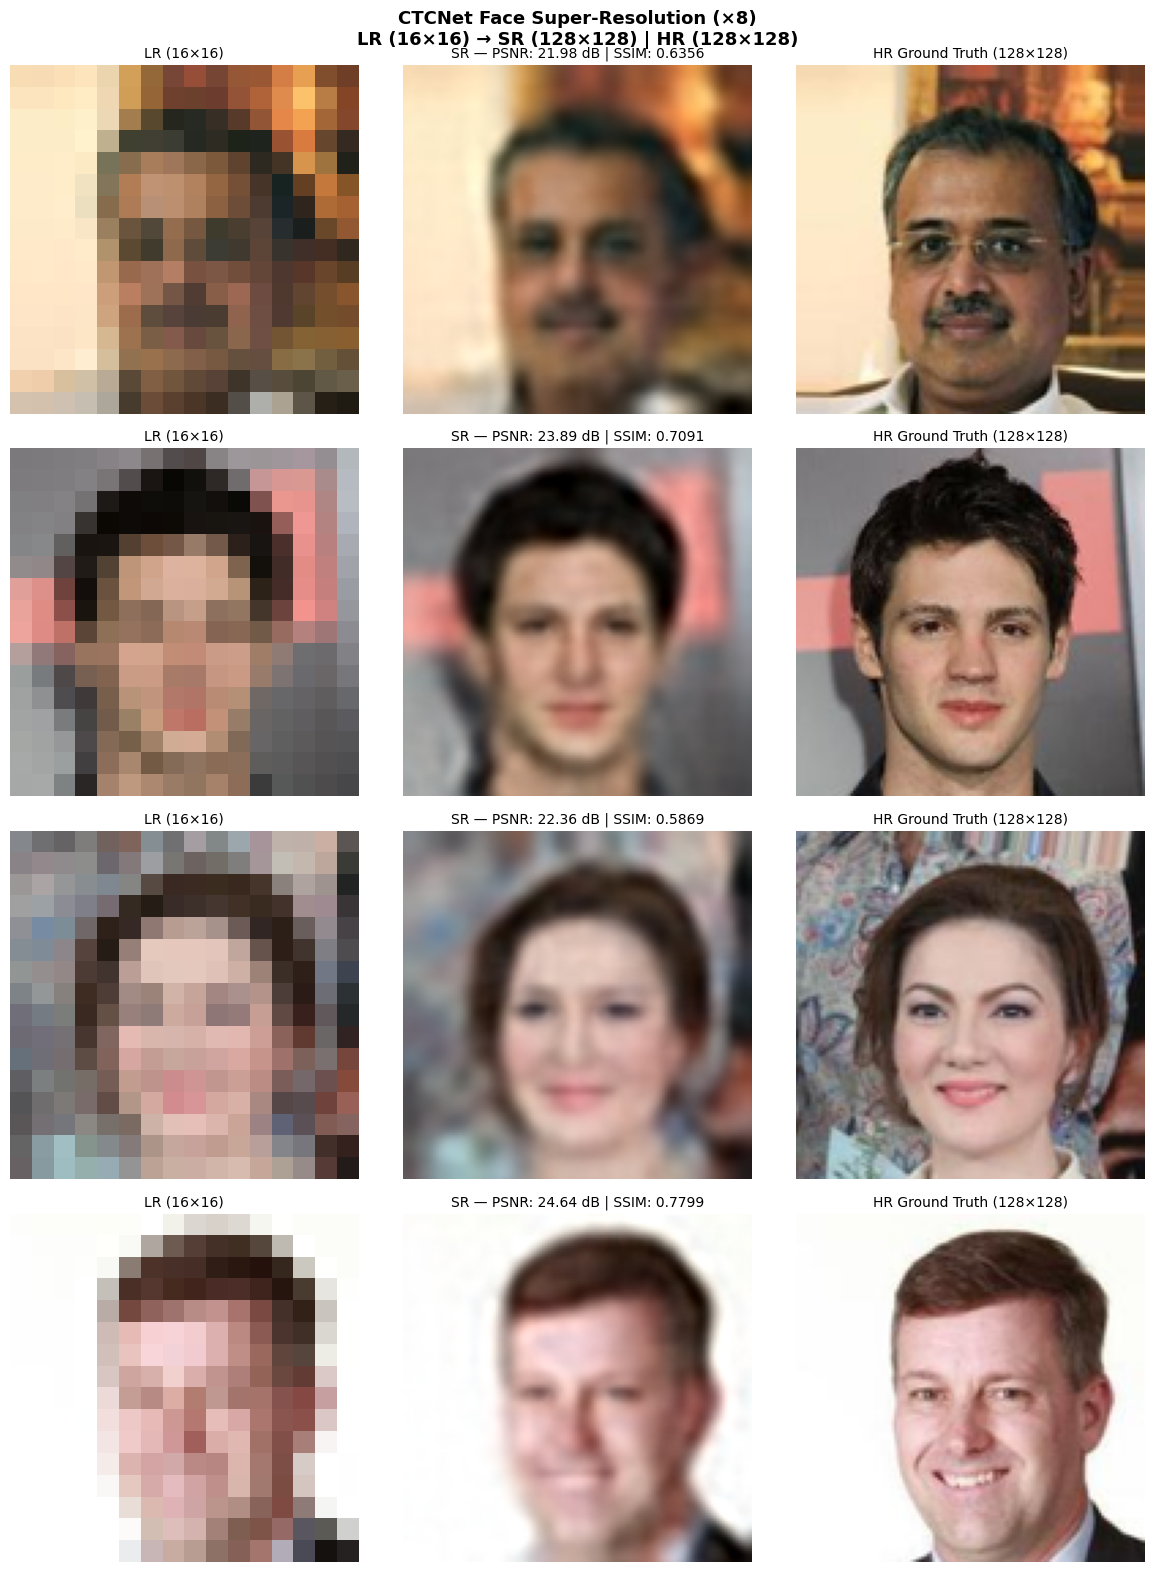

Saved: /content/ctcnet_results.png


In [44]:
# Load best checkpoint
ckpt = torch.load('/content/ctcnet_best.pth', map_location=device, weights_only=False)
model.load_state_dict(ckpt['model_state_dict'])
print(f"Loaded best model from epoch {ckpt['epoch']} with PSNR={ckpt['psnr']:.2f} dB")

def visualize_sr_results(model, dataset, n_samples=4):
    model.eval()
    indices = random.sample(range(len(dataset)), n_samples)

    fig, axes = plt.subplots(n_samples, 3, figsize=(12, 4 * n_samples))
    if n_samples == 1:
        axes = [axes]

    fig.suptitle('CTCNet Face Super-Resolution (×8)\nLR (16×16) → SR (128×128) | HR (128×128)',
                 fontsize=13, fontweight='bold')

    for row, idx in enumerate(indices):
        lr, hr = dataset[idx]
        with torch.no_grad():
            sr = model(lr.unsqueeze(0).to(device)).squeeze(0).cpu()

        psnr = compute_psnr(sr.unsqueeze(0), hr.unsqueeze(0))
        ssim = compute_ssim(sr.unsqueeze(0), hr.unsqueeze(0))

        lr_np = lr.permute(1, 2, 0).numpy().clip(0, 1)
        sr_np = sr.permute(1, 2, 0).numpy().clip(0, 1)
        hr_np = hr.permute(1, 2, 0).numpy().clip(0, 1)

        axes[row][0].imshow(lr_np)
        axes[row][0].set_title(f'LR (16×16)', fontsize=10)
        axes[row][0].axis('off')

        axes[row][1].imshow(sr_np)
        axes[row][1].set_title(f'SR — PSNR: {psnr:.2f} dB | SSIM: {ssim:.4f}', fontsize=10)
        axes[row][1].axis('off')

        axes[row][2].imshow(hr_np)
        axes[row][2].set_title('HR Ground Truth (128×128)', fontsize=10)
        axes[row][2].axis('off')

    plt.tight_layout()
    plt.savefig('/content/ctcnet_results.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: /content/ctcnet_results.png")

visualize_sr_results(model, test_dataset, n_samples=4)

## 11. Final Evaluation on Test Set

In [45]:
print("Evaluating CTCNet on test set...")
test_metrics = evaluate(model, test_loader)

print("\n" + "="*50)
print("        CTCNet Test Set Results (×8 SR)")
print("="*50)
print(f"  PSNR  : {test_metrics['PSNR']:.4f} dB")
print(f"  SSIM  : {test_metrics['SSIM']:.4f}")
print(f"  LPIPS : {test_metrics['LPIPS']:.4f} (lower = better)")
print("="*50)
print("\nPaper reports on full CelebA (18k train):")
print("  PSNR: 28.37 | SSIM: 0.8115 | LPIPS: 0.1702 | VIF: 0.4927")

Evaluating CTCNet on test set...

        CTCNet Test Set Results (×8 SR)
  PSNR  : 23.2899 dB
  SSIM  : 0.6660
  LPIPS : 0.3551 (lower = better)

Paper reports on full CelebA (18k train):
  PSNR: 28.37 | SSIM: 0.8115 | LPIPS: 0.1702 | VIF: 0.4927


## 12. Ablation Study: LGCM Components

Replicating Table I from the paper: comparing `w/o LGCM`, `LGCM w/o TB`, `LGCM w/o FSAU`, and full `LGCM`.

In [46]:
class CTCNetNoLGCM(CTCNet):
    """Replace all LGCMs with simple residual conv blocks."""
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        C = kwargs.get('base_channels', 32)
        heads = kwargs.get('num_heads', 4)
        simple = lambda c: nn.Sequential(nn.Conv2d(c,c,3,padding=1), nn.LeakyReLU(0.2,True), nn.Conv2d(c,c,3,padding=1))
        self.enc_lgcm1 = simple(C)
        self.enc_lgcm2 = simple(C*2)
        self.enc_lgcm3 = simple(C*4)
        self.dec_lgcm1 = simple(C*4)
        self.dec_lgcm2 = simple(C*2)
        self.dec_lgcm3 = simple(C)


class LGCMnoTB(nn.Module):
    """LGCM without Transformer Block — FSAU only."""
    def __init__(self, channels, num_heads=4):
        super().__init__()
        self.fsau = FSAU(channels)
    def forward(self, x):
        return self.fsau(x)


class LGCMnoFSAU(nn.Module):
    """LGCM without FSAU — Transformer Block only."""
    def __init__(self, channels, num_heads=4):
        super().__init__()
        self.transformer = TransformerBlock(channels, num_heads)
    def forward(self, x):
        return self.transformer(x)


def make_ctcnet_variant(lgcm_class, base_channels=32, num_frm=4, num_heads=4):
    """Build CTCNet with a custom LGCM class."""
    model = CTCNet(base_channels=base_channels, num_frm=num_frm, num_heads=num_heads).to(device)
    C = base_channels
    model.enc_lgcm1 = lgcm_class(C, num_heads).to(device)
    model.enc_lgcm2 = lgcm_class(C*2, num_heads).to(device)
    model.enc_lgcm3 = lgcm_class(C*4, num_heads).to(device)
    model.dec_lgcm1 = lgcm_class(C*4, num_heads).to(device)
    model.dec_lgcm2 = lgcm_class(C*2, num_heads).to(device)
    model.dec_lgcm3 = lgcm_class(C, num_heads).to(device)
    return model


def quick_train(model, epochs=5):
    """Quick training for ablation (few epochs)."""
    opt = optim.Adam(model.parameters(), lr=2e-4, betas=(0.9, 0.99))
    model.train()
    for ep in range(epochs):
        for lr_b, hr_b in train_loader:
            lr_b, hr_b = lr_b.to(device), hr_b.to(device)
            loss = F.l1_loss(model(lr_b), hr_b)
            opt.zero_grad(); loss.backward(); opt.step()
    return model


# ── Run ablation ─────────────────────────────────────────────────────────────
print("Running LGCM ablation study (Table I replication)...")
print("(Using only 5 quick training epochs for demo — paper uses full training)\n")

ablation_results = {}

variants = [
    ('Full LGCM (Ours)', LGCM),
    ('LGCM w/o TB',     LGCMnoTB),
    ('LGCM w/o FSAU',   LGCMnoFSAU),
]

for name, cls in variants:
    print(f"Training: {name}...")
    m = make_ctcnet_variant(cls)
    m = quick_train(m, epochs=5)
    metrics = evaluate(m, val_loader, max_batches=10)
    ablation_results[name] = metrics
    print(f"  PSNR={metrics['PSNR']:.2f} | SSIM={metrics['SSIM']:.4f} | LPIPS={metrics['LPIPS']:.4f}")

print("\n" + "="*65)
print(f"{'Method':<22} {'PSNR (dB)':>10} {'SSIM':>10} {'LPIPS (↓)':>12}")
print("-"*65)
for name, m in ablation_results.items():
    print(f"{name:<22} {m['PSNR']:>10.4f} {m['SSIM']:>10.4f} {m['LPIPS']:>12.4f}")
print("="*65)
print("\nPaper Table I (full training on CelebA):")
print("  w/o LGCM:      PSNR=27.56 | SSIM=0.7867")
print("  LGCM w/o TB:   PSNR=27.82 | SSIM=0.7964")
print("  LGCM w/o FSAU: PSNR=27.83 | SSIM=0.7972")
print("  Full LGCM:     PSNR=27.90 | SSIM=0.7980")

Running LGCM ablation study (Table I replication)...
(Using only 5 quick training epochs for demo — paper uses full training)

Training: Full LGCM (Ours)...
  PSNR=23.26 | SSIM=0.6592 | LPIPS=0.3689
Training: LGCM w/o TB...
  PSNR=22.87 | SSIM=0.6405 | LPIPS=0.4231
Training: LGCM w/o FSAU...
  PSNR=23.18 | SSIM=0.6556 | LPIPS=0.3796

Method                  PSNR (dB)       SSIM    LPIPS (↓)
-----------------------------------------------------------------
Full LGCM (Ours)          23.2596     0.6592       0.3689
LGCM w/o TB               22.8679     0.6405       0.4231
LGCM w/o FSAU             23.1817     0.6556       0.3796

Paper Table I (full training on CelebA):
  w/o LGCM:      PSNR=27.56 | SSIM=0.7867
  LGCM w/o TB:   PSNR=27.82 | SSIM=0.7964
  LGCM w/o FSAU: PSNR=27.83 | SSIM=0.7972
  Full LGCM:     PSNR=27.90 | SSIM=0.7980


## 13. CTCGAN Training (Optional — GAN Extension)

The paper also proposes CTCGAN with pixel + perceptual + adversarial losses.  
Enable the cell below to train with GAN (significantly slower).

Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth


100%|██████████| 548M/548M [00:06<00:00, 95.5MB/s]


No pre-trained weights found, training from scratch.
Training CTCGAN for 10 epochs...
CTCGAN Epoch [01/10] G_loss: 0.0784 | D_loss: 1.1589
CTCGAN Epoch [02/10] G_loss: 0.0887 | D_loss: 0.7449
CTCGAN Epoch [03/10] G_loss: 0.1067 | D_loss: 0.6200
CTCGAN Epoch [04/10] G_loss: 0.1061 | D_loss: 0.6170
CTCGAN Epoch [05/10] G_loss: 0.1112 | D_loss: 0.5262
CTCGAN Epoch [06/10] G_loss: 0.1139 | D_loss: 0.4164
CTCGAN Epoch [07/10] G_loss: 0.1126 | D_loss: 0.5343
CTCGAN Epoch [08/10] G_loss: 0.1164 | D_loss: 0.6026
CTCGAN Epoch [09/10] G_loss: 0.1220 | D_loss: 0.5609
CTCGAN Epoch [10/10] G_loss: 0.1150 | D_loss: 0.5158

✅ CTCGAN training complete.
Visualizing GAN results...


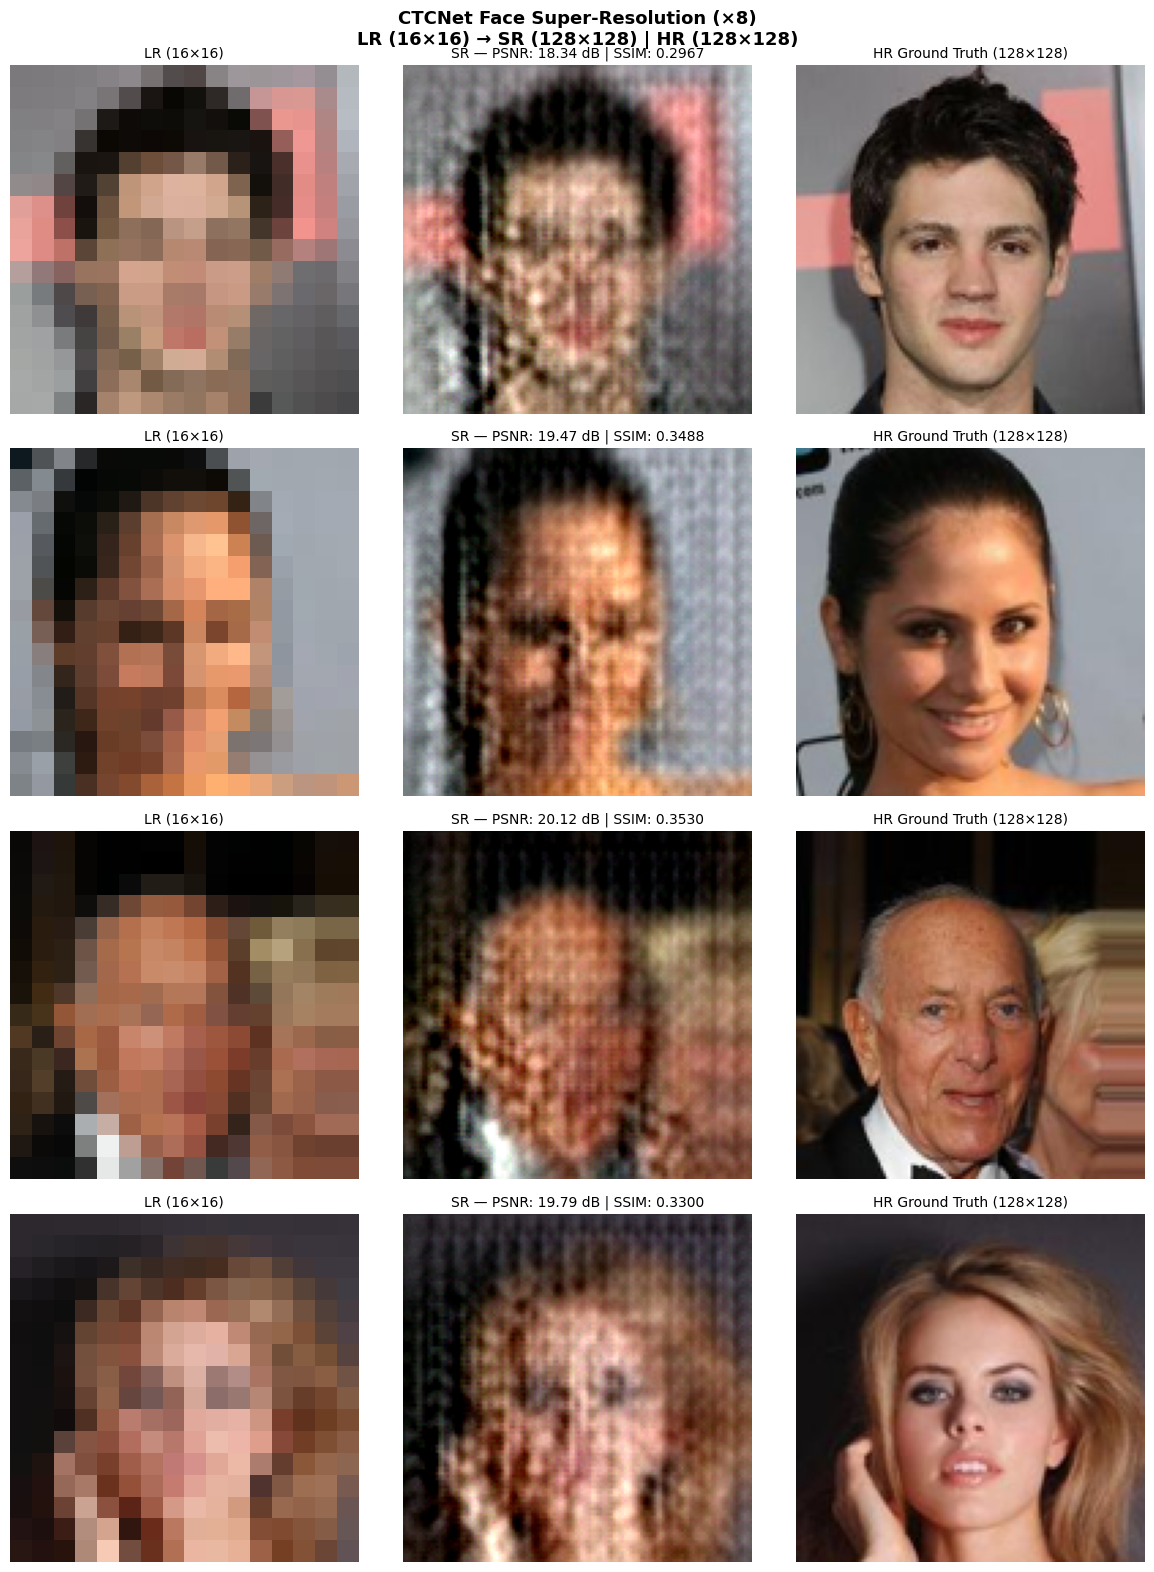

Saved: /content/ctcnet_results.png


In [48]:
TRAIN_GAN = True  # Set to True to enable GAN training

if TRAIN_GAN:
    import warnings
    warnings.filterwarnings('ignore')

    generator = CTCNet(base_channels=32, num_frm=4, num_heads=4, scale=8).to(device)
    discriminator = Discriminator(in_channels=3).to(device)
    perceptual_loss = VGGPerceptualLoss().to(device)

    # Load pre-trained CTCNet weights to bootstrap GAN
    try:
        ckpt = torch.load('/content/ctcnet_best.pth', map_location=device)
        generator.load_state_dict(ckpt['model_state_dict'])
        print("Loaded pre-trained CTCNet weights for GAN initialization.")
    except:
        print("No pre-trained weights found, training from scratch.")

    # Paper: λpix=1, λpcp=0.01, λadv=0.01
    lambda_pix, lambda_pcp, lambda_adv = 1.0, 0.01, 0.01

    opt_G = optim.Adam(generator.parameters(), lr=1e-4, betas=(0.9, 0.99))
    opt_D = optim.Adam(discriminator.parameters(), lr=4e-4, betas=(0.9, 0.99))

    GAN_EPOCHS = 10
    print(f"Training CTCGAN for {GAN_EPOCHS} epochs...")

    for epoch in range(1, GAN_EPOCHS + 1):
        generator.train()
        discriminator.train()
        g_losses, d_losses = [], []

        for lr_b, hr_b in train_loader:
            lr_b, hr_b = lr_b.to(device), hr_b.to(device)
            lr_up = F.interpolate(lr_b, scale_factor=8, mode='bicubic', align_corners=False)

            # ── Train Discriminator (Eq. 19) ────────────────────────────────
            with torch.no_grad():
                sr = generator(lr_b)

            real_out = discriminator(lr_up, hr_b)
            fake_out = discriminator(lr_up, sr.detach())
            d_loss = (-torch.log(torch.sigmoid(real_out) + 1e-8) -
                       torch.log(1 - torch.sigmoid(fake_out) + 1e-8)).mean()

            opt_D.zero_grad()
            d_loss.backward()
            opt_D.step()

            # ── Train Generator (Eq. 21) ─────────────────────────────────────
            sr = generator(lr_b)
            fake_out_g = discriminator(lr_up, sr)

            l_pix = F.l1_loss(sr, hr_b)
            l_pcp = perceptual_loss(sr, hr_b)
            l_adv = -torch.log(torch.sigmoid(fake_out_g) + 1e-8).mean()

            g_loss = lambda_pix * l_pix + lambda_pcp * l_pcp + lambda_adv * l_adv

            opt_G.zero_grad()
            g_loss.backward()
            opt_G.step()

            g_losses.append(g_loss.item())
            d_losses.append(d_loss.item())

        print(f"CTCGAN Epoch [{epoch:02d}/{GAN_EPOCHS}] "
              f"G_loss: {np.mean(g_losses):.4f} | D_loss: {np.mean(d_losses):.4f}")

    torch.save(generator.state_dict(), '/content/ctcgan_generator.pth')
    print("\n✅ CTCGAN training complete.")
    print("Visualizing GAN results...")
    visualize_sr_results(generator, test_dataset, n_samples=4)
else:
    print("GAN training skipped. Set TRAIN_GAN=True to enable.")

## 14. Inference on Custom Images

In [ ]:
def super_resolve_image(model, image_path_or_pil, scale=8, device=device):
    """
    Super-resolve a single face image.
    Input can be a file path or a PIL Image.
    The image is treated as LR input.
    """
    model.eval()

    if isinstance(image_path_or_pil, str):
        img = Image.open(image_path_or_pil).convert('RGB')
    else:
        img = image_path_or_pil

    lr_tensor = transforms.ToTensor()(img).unsqueeze(0).to(device)  # 1,3,H,W

    with torch.no_grad():
        sr_tensor = model(lr_tensor).squeeze(0).cpu()

    sr_img = transforms.ToPILImage()(sr_tensor.clamp(0, 1))
    return sr_img


def demo_inference(model, test_dataset, n=3):
    """Demo: take LR images from test set and super-resolve them."""
    model.eval()
    fig, axes = plt.subplots(n, 2, figsize=(8, 4 * n))
    if n == 1:
        axes = [axes]
    fig.suptitle('CTCNet Inference Demo\n(Left: Input LR, Right: Super-Resolved)', fontsize=12)

    for i in range(n):
        lr, hr = test_dataset[i]
        lr_pil = transforms.ToPILImage()(lr)

        sr_pil = super_resolve_image(model, lr_pil, scale=8)

        axes[i][0].imshow(lr_pil)
        axes[i][0].set_title(f'LR Input ({lr.shape[1]}×{lr.shape[2]})')
        axes[i][0].axis('off')

        axes[i][1].imshow(sr_pil)
        axes[i][1].set_title(f'SR Output ({sr_pil.size[0]}×{sr_pil.size[1]})')
        axes[i][1].axis('off')

    plt.tight_layout()
    plt.savefig('/content/ctcnet_inference_demo.png', dpi=150, bbox_inches='tight')
    plt.show()


demo_inference(model, test_dataset, n=3)
print("Saved: /content/ctcnet_inference_demo.png")

## 15. Model Summary & Paper Results

### Paper Quantitative Results (CelebA ×8 SR)

| Method | PSNR↑ | SSIM↑ | VIF↑ | LPIPS↓ |
|--------|-------|-------|------|--------|
| Bicubic | 23.61 | 0.6779 | 0.1821 | 0.4899 |
| SAN | 27.43 | 0.7826 | 0.4553 | 0.2080 |
| SwinIR | 27.88 | 0.7967 | 0.4590 | 0.2001 |
| SPARNet | 27.73 | 0.7949 | 0.4505 | 0.1995 |
| SISN | 27.91 | 0.7971 | 0.4785 | 0.2005 |
| **CTCNet (Ours)** | **28.37** | **0.8115** | **0.4927** | **0.1702** |

### Training Tips
- Paper uses **18,000 CelebA** images, 128×128 HR center crops
- **Adam** optimizer: β₁=0.9, β₂=0.99, lr=2×10⁻⁴
- **4 FRMs** in bottleneck gives best PSNR/parameter tradeoff (Table II)
- For CTCGAN: λ_pix=1, λ_pcp=0.01, λ_adv=0.01
- Increase `base_channels` to 64 for closer match to paper's ~21M parameter model

In [49]:
# ── Final summary ─────────────────────────────────────────────────────────────
print("╔══════════════════════════════════════════════════════╗")
print("║           CTCNet Notebook Summary                   ║")
print("╠══════════════════════════════════════════════════════╣")
print("║  Components implemented:                            ║")
print("║   ✅ AFDU  - Adaptive Feature Distillation Unit     ║")
print("║   ✅ FSAU  - Facial Structure Attention Unit        ║")
print("║   ✅ MDTA  - Multi-Dconv Head Transposed Attention  ║")
print("║   ✅ GDFN  - Gated-Dconv Feed-Forward Network       ║")
print("║   ✅ LGCM  - Local-Global Feature Cooperation Mod.  ║")
print("║   ✅ FEU   - Feature Enhancement Unit               ║")
print("║   ✅ FRM   - Feature Refinement Module              ║")
print("║   ✅ MFFU  - Multi-scale Feature Fusion Unit        ║")
print("║   ✅ CTCNet - Full Architecture                     ║")
print("║   ✅ CTCGAN - GAN Extension (optional)              ║")
print("║   ✅ Metrics: PSNR, SSIM, LPIPS                     ║")
print("║   ✅ Ablation study: LGCM components (Table I)      ║")
print("╚══════════════════════════════════════════════════════╝")

# Parameter count breakdown
model_eval = CTCNet(base_channels=32, num_frm=4).to(device)
def count_params(m): return sum(p.numel() for p in m.parameters())

print(f"\nParameter counts (base_channels=32):")
print(f"  Full CTCNet:     {count_params(model_eval):>10,}")
print(f"  Encoder LGCMs:   {count_params(model_eval.enc_lgcm1)+count_params(model_eval.enc_lgcm2)+count_params(model_eval.enc_lgcm3):>10,}")
print(f"  Bottleneck FRMs: {count_params(model_eval.bottleneck):>10,}")
print(f"  Decoder LGCMs:   {count_params(model_eval.dec_lgcm1)+count_params(model_eval.dec_lgcm2)+count_params(model_eval.dec_lgcm3):>10,}")

╔══════════════════════════════════════════════════════╗
║           CTCNet Notebook Summary                   ║
╠══════════════════════════════════════════════════════╣
║  Components implemented:                            ║
║   ✅ AFDU  - Adaptive Feature Distillation Unit     ║
║   ✅ FSAU  - Facial Structure Attention Unit        ║
║   ✅ MDTA  - Multi-Dconv Head Transposed Attention  ║
║   ✅ GDFN  - Gated-Dconv Feed-Forward Network       ║
║   ✅ LGCM  - Local-Global Feature Cooperation Mod.  ║
║   ✅ FEU   - Feature Enhancement Unit               ║
║   ✅ FRM   - Feature Refinement Module              ║
║   ✅ MFFU  - Multi-scale Feature Fusion Unit        ║
║   ✅ CTCNet - Full Architecture                     ║
║   ✅ CTCGAN - GAN Extension (optional)              ║
║   ✅ Metrics: PSNR, SSIM, LPIPS                     ║
║   ✅ Ablation study: LGCM components (Table I)      ║
╚══════════════════════════════════════════════════════╝

Parameter counts (base_channels=32):
  Full CTCNet:     